# Process the Load Data for the WPTO Polar Vortex Case Study


In [1]:
# Start by importing the packages we need:
import os
import glob
import datetime
import warnings
import pytz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Set the Directory Structure

In [2]:
# Identify the data input and image output directory:
data_dir =  '/Users/burl878/Documents/Code/code_repos/wpto_polar_vortex_2024_case/data/'
plot_dir =  '/Users/burl878/Documents/Code/code_repos/wpto_polar_vortex_2024_case/plots/'


## Suppress Future Warnings


In [3]:
warnings.simplefilter(action='ignore', category=FutureWarning)


## Create a Function to Aggregate the Historical EIA-930 Loads into a Single Dataframe


In [4]:
def aggregate_eia_930_files(data_dir: str, year_to_process: int):
    
    # Create a list of all of the MLP output files in the "mlp_input_dir" and aggregate the files in that list:
    list_of_files = sorted(glob.glob(os.path.join(data_dir, 'TELL_Output', '*.csv')))

    # Loop over the list of MLP output files:
    for file in range(len(list_of_files)):
       
        # Read in the .csv file and replace missing values with nan:
        temp_df = pd.read_csv(list_of_files[file])

        # Add in the load area:
        temp_df['BA'] = os.path.splitext(os.path.basename(str(list_of_files[file])))[0].replace(".csv", "")

        # Round the demand to two digits and rename the variable:
        temp_df['Raw_Demand_MWh'] = temp_df['Cleaned_Demand_MWh'].round(2)

        # Replace missing values with the TELL MLP value:
        temp_df.loc[temp_df['Raw_Demand_MWh'].isnull(),'Raw_Demand_MWh'] = temp_df['Projected_Demand_MWh']
        
        # Subset to just the variables we need:
        temp_df = temp_df[['BA', 'Time_UTC', 'Raw_Demand_MWh']].copy(deep=False).reset_index(drop=True)
    
        # Convert the time columns into one datetime variable:
        temp_df['Time_UTC'] = pd.to_datetime(temp_df['Time_UTC'])

        # Convert the timezone:
        local_timezone = pytz.timezone('America/Denver')
        temp_df['Time_Local'] = temp_df['Time_UTC'].dt.tz_localize('UTC').dt.tz_convert(local_timezone).dt.tz_localize(None)
                
        # Subset to just the year being processed. Note because 2024 is a leap year we cut off the last day of data to match what's in the original GV file:
        temp_df = temp_df.loc[(temp_df['Time_Local'] >= pd.to_datetime((str(year_to_process) + '-1-1 00:00:00'), format="%Y-%m-%d %H:%M:%S")) & 
                              (temp_df['Time_Local'] <= pd.to_datetime((str(year_to_process) + '-12-30 23:00:00'), format="%Y-%m-%d %H:%M:%S"))].reset_index(drop=True)

        # Concatenate the data from multiple load areas:
        if file == 0:
          load_df = temp_df.copy()
        else:
          load_df = pd.concat([load_df, temp_df])

    # Subset to just the variables we need:
    load_df = load_df[['BA', 'Time_Local', 'Raw_Demand_MWh']].copy(deep=False).reset_index(drop=True)
        
    # Sort so I can triage the names:
    load_df = load_df.sort_values(by=['BA', 'Time_Local'])

    # Return the output dataframe:
    return load_df


In [5]:
# Test the function:
load_df = aggregate_eia_930_files(data_dir = data_dir,
                                  year_to_process = 2024)

load_df


,BA,Time_Local,Raw_Demand_MWh
0,AVA,2024-01-01 00:00:00,1411.0
1,AVA,2024-01-01 01:00:00,1369.0
2,AVA,2024-01-01 02:00:00,1334.0
3,AVA,2024-01-01 03:00:00,1315.0
4,AVA,2024-01-01 04:00:00,1290.0
...,...,...,...
271555,WAUW,2024-12-30 19:00:00,99.0
271556,WAUW,2024-12-30 20:00:00,101.0
271557,WAUW,2024-12-30 21:00:00,97.0
271558,WAUW,2024-12-30 22:00:00,96.0


## Create a Function to Process the 2030 WECC ADS GridView Data Used in Scaling


In [6]:
def process_gridview_data(data_dir: str):
    
    # Read in the raw data .csv file:
    gv_df = pd.read_csv((data_dir + 'EEI_Format_Data_2030_Load.csv'))

    # Subset to just the annual total demand by BA:
    gv_df = gv_df[-3:-2]
       
    # Strip the unecessary bits from the column names:
    gv_df.columns = gv_df.columns.str.replace("_CEC", "")
    gv_df.columns = gv_df.columns.str.replace("_2030.dat", "")
    gv_df.columns = gv_df.columns.str.replace("Load_", "")
       
    # Delete the index and last column:
    del gv_df["Index"]

    # Convert the loads to floating point:
    gv_df = gv_df.astype(float, copy=False, errors='raise')

    # Compute the total loads for CISO, IPCO, NEVP, and PACE:
    gv_df['PGAE'] = (gv_df['CIPB'] + gv_df['CIPV']).round(2)
    gv_df['IPCO'] = (gv_df['IPFE'] + gv_df['IPMV'] + gv_df['IPTV']).round(2)
    gv_df['PACE'] = (gv_df['PAID'] + gv_df['PAUT'] + gv_df['PAWY']).round(2)
    gv_df['NEVP_Sum'] = (gv_df['NEVP'] + gv_df['SPPC']).round(2)
           
    # Rename a few columns for consistency:
    gv_df.rename(columns={'CIPB': 'CISO_CIPB', 'CIPV': 'CISO_CIPV',
                          'IPFE': 'IPCO_IPFE', 'IPMV': 'IPCO_IPMV', 'IPTV': 'IPCO_IPTV',
                          'NEVP': 'NEVP_NEVP', 'SPPC': 'NEVP_SPPC',
                          'PAID': 'PACE_PAID', 'PAUT': 'PACE_PAUT', 'PAWY': 'PACE_PAWY'}, inplace=True) 
    gv_df.rename(columns={'NEVP_Sum': 'NEVP'}, inplace=True) 
    
    # Squeeze the dataframe:
    gv_df = gv_df.squeeze().to_frame()
        
    # Rename the columns:
    gv_df.reset_index(inplace=True)
    gv_df = gv_df.rename(columns = {'index':'BA'})
    gv_df.rename(columns={gv_df.columns[1]: "Total_Load_MWh" }, inplace = True)

    # Sort the dataframe alphabetically by BA name:
    gv_df = gv_df.sort_values('BA')
       
    # Return the output dataframe:
    return gv_df


In [7]:
# Test the function:
gv_df = process_gridview_data(data_dir = data_dir)

gv_df


,BA,Total_Load_MWh
0,AESO,96300000.0
1,AVA,13700000.0
2,AZPS,43200000.0
3,BANC,18600000.0
4,BCHA,65700000.0
5,BPAT,69300000.0
6,CFE,22000000.0
7,CHPD,1971675.0
10,CISC,110000000.0
11,CISD,24400000.0


In [8]:
# Print the list of unique BAs:
print(gv_df['BA'].unique())

# Print the list of unique BAs:
print(load_df['BA'].unique())


['AESO' 'AVA' 'AZPS' 'BANC' 'BCHA' 'BPAT' 'CFE' 'CHPD' 'CISC' 'CISD'
 'CISO_CIPB' 'CISO_CIPV' 'DOPD' 'EPE' 'GCPD' 'IID' 'IPCO' 'IPCO_IPFE'
 'IPCO_IPMV' 'IPCO_IPTV' 'LDWP' 'NEVP' 'NEVP_NEVP' 'NEVP_SPPC' 'NWMT'
 'PACE' 'PACE_PAID' 'PACE_PAUT' 'PACE_PAWY' 'PACW' 'PGAE' 'PGE' 'PNM'
 'PSCO' 'PSEI' 'SCL' 'SRP' 'TEPC' 'TH_Malin' 'TH_Mead' 'TH_PV' 'TIDC'
 'TPWR' 'VEA' 'WACM' 'WALC' 'WAUW']
['AVA' 'AZPS' 'BANC' 'BPAT' 'CHPD' 'CISC' 'CISD' 'DOPD' 'EPE' 'GCPD' 'IID'
 'IPCO' 'LDWP' 'NEVP' 'NWMT' 'PACE' 'PACW' 'PGAE' 'PGE' 'PNM' 'PSCO'
 'PSEI' 'SCL' 'SRP' 'TEPC' 'TIDC' 'TPWR' 'VEA' 'WACM' 'WALC' 'WAUW']


## Create a Function to Scale the EIA-930 Loads to the Annual Energies in the 2030 WECC ADS GridView Data:


In [37]:
def scale_eia930_loads(data_dir: str, year_to_process: int):
    
    # Aggregate the EIA 930 data:
    load_df = aggregate_eia_930_files(data_dir = data_dir,
                                      year_to_process = year_to_process)
    
    # Read in the processed GridView file and rename a column for consistency:
    gv_df = process_gridview_data(data_dir = data_dir)
    gv_df.rename(columns={'Total_Load_MWh': 'GV_Total_Load_MWh'}, inplace=True) 
    
    # Merge the tell_df and gv_df dataframes based on common BA names:
    merged_df = load_df.merge(gv_df, on=['BA'])
    
    # Sum the hourly TELL loads by BA into annual total loads:
    merged_df['EIA930_Total_Load_MWh'] = merged_df.groupby('BA')['Raw_Demand_MWh'].transform('sum')
    
    # Compute the scaling factors that force the annual total loads to agree:
    merged_df['Scaling_Factor'] = merged_df['GV_Total_Load_MWh'] / merged_df['EIA930_Total_Load_MWh']
    
    # Compute the scaled hourly loads:
    merged_df['Scaled_Demand_MWh'] = (merged_df['Raw_Demand_MWh'] * merged_df['Scaling_Factor']).round(2)

    # Compute the hours since the start of the year:
    merged_df['Hour'] = ((pd.to_datetime(merged_df['Time_Local']) - datetime.datetime(year_to_process, 1, 1, 0, 0, 0)) / np.timedelta64(1, 'h') + 1).astype(int)

    # Save the data so I can inspect it:
    merged_df.to_csv((os.path.join(data_dir, 'Test.csv')), sep=',', index=False)
    
    # Only keep the columns that are needed:
    scaled_demand_df = merged_df[['Hour', 'BA', 'Scaled_Demand_MWh']].copy().drop_duplicates().reset_index(drop=True)
    
    # Drop the rows with missing values (i.e., there is not a corresponding GridView load):
    scaled_demand_df = scaled_demand_df.dropna(how='any')
    
    # Return the output dataframe:
    return scaled_demand_df


In [38]:
# Test the function:
output_df = scale_eia930_loads(data_dir = data_dir,
                               year_to_process = 2024)

output_df


,Hour,BA,Scaled_Demand_MWh
0,1,AVA,1497.39
1,2,AVA,1452.82
2,3,AVA,1415.68
3,4,AVA,1395.51
4,5,AVA,1368.98
...,...,...,...
271555,8756,WAUW,103.88
271556,8757,WAUW,105.98
271557,8758,WAUW,101.79
271558,8759,WAUW,100.74


## Create a Function to Format the Output for Ingest to GridView:


In [31]:
def format_scaled_eia930_loads(data_dir: str, year_to_process: str):
    
    # Process the GridView file:
    gv_df = process_gridview_data(data_dir = data_dir)
    
    # Compute the load fractions for the subregions:
    CIPB_LF = (gv_df.loc[(gv_df['BA'] == 'CISO_CIPB')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'PGAE')]['Total_Load_MWh'].values[0])
    CIPV_LF = (gv_df.loc[(gv_df['BA'] == 'CISO_CIPV')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'PGAE')]['Total_Load_MWh'].values[0])
    IPFE_LF = (gv_df.loc[(gv_df['BA'] == 'IPCO_IPFE')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'IPCO')]['Total_Load_MWh'].values[0])
    IPMV_LF = (gv_df.loc[(gv_df['BA'] == 'IPCO_IPMV')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'IPCO')]['Total_Load_MWh'].values[0])
    IPTV_LF = (gv_df.loc[(gv_df['BA'] == 'IPCO_IPTV')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'IPCO')]['Total_Load_MWh'].values[0])
    NEVP_LF = (gv_df.loc[(gv_df['BA'] == 'NEVP_NEVP')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'NEVP')]['Total_Load_MWh'].values[0])
    SPPC_LF = (gv_df.loc[(gv_df['BA'] == 'NEVP_SPPC')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'NEVP')]['Total_Load_MWh'].values[0])
    PAID_LF = (gv_df.loc[(gv_df['BA'] == 'PACE_PAID')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'PACE')]['Total_Load_MWh'].values[0])
    PAUT_LF = (gv_df.loc[(gv_df['BA'] == 'PACE_PAUT')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'PACE')]['Total_Load_MWh'].values[0])
    PAWY_LF = (gv_df.loc[(gv_df['BA'] == 'PACE_PAWY')]['Total_Load_MWh'].values[0]) / (gv_df.loc[(gv_df['BA'] == 'PACE')]['Total_Load_MWh'].values[0])
    
    # Aggregate the TELL MLP files:
    scaled_eia930_df = scale_eia930_loads(data_dir = data_dir,
                                          year_to_process = year_to_process)
   
    # Reshape the dataframe and drop the indexes:
    load_df = scaled_eia930_df.pivot_table(index = 'Hour', columns = 'BA', values = 'Scaled_Demand_MWh', aggfunc='mean')
    #load_df = output_df.pivot_table(index='Hour', columns='BA', values='Scaled_Demand_MWh', aggfunc='mean')
    load_df = load_df.reset_index(drop=False)
    
    # Add back in the text to the column headers:
    load_df = load_df.add_suffix('_2030.dat')
    load_df = load_df.add_prefix('Load_')
    
    # Rename the time variable:
    load_df.rename(columns={'Load_Hour_2030.dat': 'Index'}, inplace=True)
    
    # Compute the loads for the subregions:
    load_df['Load_CIPB_2030_CEC.dat'] = (load_df['Load_PGAE_2030.dat'] * CIPB_LF).round(2)
    load_df['Load_CIPV_2030_CEC.dat'] = (load_df['Load_PGAE_2030.dat'] * CIPV_LF).round(2)
    load_df['Load_IPFE_2030.dat'] = (load_df['Load_IPCO_2030.dat'] * IPFE_LF).round(2)
    load_df['Load_IPMV_2030.dat'] = (load_df['Load_IPCO_2030.dat'] * IPMV_LF).round(2)
    load_df['Load_IPTV_2030.dat'] = (load_df['Load_IPCO_2030.dat'] * IPTV_LF).round(2)
    load_df['Load_NEVP_Temp_2030.dat'] = (load_df['Load_NEVP_2030.dat'] * NEVP_LF).round(2)
    load_df['Load_SPPC_2030.dat'] = (load_df['Load_NEVP_2030.dat'] * SPPC_LF).round(2)
    load_df['Load_PAID_2030.dat'] = (load_df['Load_PACE_2030.dat'] * PAID_LF).round(2)
    load_df['Load_PAUT_2030.dat'] = (load_df['Load_PACE_2030.dat'] * PAUT_LF).round(2)
    load_df['Load_PAWY_2030.dat'] = (load_df['Load_PACE_2030.dat'] * PAWY_LF).round(2)
    
    # Drop the un-needed columns for BAs with subregions:
    del load_df['Load_NEVP_2030.dat'], load_df['Load_PGAE_2030.dat'], load_df['Load_IPCO_2030.dat'], load_df['Load_PACE_2030.dat']
    
    # Clean up the NEVP naming:
    load_df.rename(columns={'Load_NEVP_Temp_2030.dat': 'Load_NEVP_2030.dat'}, inplace=True)

    # Drop the rows with missing values (i.e., there is not a corresponding GridView load):
    load_df = load_df.dropna(how='any', axis=0)
    
    # Read in the raw data GridView .csv file:
    raw_gv_df = pd.read_csv((data_dir + 'EEI_Format_Data_2030_Load.csv'))
    
    # Delete the index column:
    del raw_gv_df["Index"] 
    
    # Subset to just the rows we need:
    raw_gv_df = raw_gv_df[1:8761]
    
    # Convert the values to floats:
    raw_gv_df = raw_gv_df.astype('float64')
    
    # Shift the index by -1:
    raw_gv_df = raw_gv_df.reset_index()
    
    # Merge in the GridView columns that aren't included in the EIA-930 data:
    load_df = pd.concat([load_df,raw_gv_df['Load_AESO_2030.dat']], axis=1)
    load_df = pd.concat([load_df,raw_gv_df['Load_BCHA_2030.dat']], axis=1)
    load_df = pd.concat([load_df,raw_gv_df['Load_CFE_2030.dat']], axis=1)
    load_df = pd.concat([load_df,raw_gv_df['Load_TH_Malin_2030.dat']], axis=1)
    load_df = pd.concat([load_df,raw_gv_df['Load_TH_Mead_2030.dat']], axis=1)
    load_df = pd.concat([load_df,raw_gv_df['Load_TH_PV_2030.dat']], axis=1)

    # Create a target dataframe with the spare hours:
    target_df = pd.DataFrame({"Index": np.arange(1,8791,1)})
    
    # Merge load dataframe with the target dataframe:
    merged_df = target_df.merge(load_df, on=['Index'], how='left')

    # Compute the summary statistics:
    stats_df = merged_df.apply(['mean','sum','max','min'])
    
    # Fix the summary statistic labels:
    stats_df.iloc[0, 0] = 'AVG'
    stats_df.iloc[1, 0] = 'SUM'
    stats_df.iloc[2, 0] = 'MAX'
    stats_df.iloc[3, 0] = 'MIN'
      
    # Sort the data by column name and make the Index column appear first:
    merged_df.rename(columns={'Index': 'AA'}, inplace=True)
    merged_df = merged_df.sort_index(axis = 1)
    merged_df.rename(columns={'AA': 'Index'}, inplace=True)
    
    # Add in a blank row and fill it with the year placeholder:
    merged_df.loc[-0.5] = 0
    merged_df = merged_df.sort_index().reset_index(drop=True)
    merged_df.iloc[0, :] = '2030'
    merged_df.at[0, 'Index'] = 'Year'
        
    # Merge the hourly load data and statistics dataframes together:
    output_df = pd.concat([merged_df, stats_df], axis=0)
    
    # Replace NaNs with blank values:
    output_df.replace(np.nan, "", regex=True)
    
    # Set the output filename:
    output_filename = 'EIA930_Loads_Scaled_to_2030_ADS_Annual_Energy.csv'
    
    # Write out the dataframe to a .csv file:
    output_df.to_csv((os.path.join(data_dir, output_filename)), sep=',', index=False)
    
    # Return the output dataframe:
    return output_df


## Process the Data:


In [32]:
output_df = format_scaled_eia930_loads(data_dir = data_dir,
                                       year_to_process = 2024)

output_df


,Index,Load_AESO_2030.dat,Load_AVA_2030.dat,Load_AZPS_2030.dat,Load_BANC_2030.dat,Load_BCHA_2030.dat,Load_BPAT_2030.dat,Load_CFE_2030.dat,Load_CHPD_2030.dat,Load_CIPB_2030_CEC.dat,...,Load_TEPC_2030.dat,Load_TH_Malin_2030.dat,Load_TH_Mead_2030.dat,Load_TH_PV_2030.dat,Load_TIDC_2030.dat,Load_TPWR_2030.dat,Load_VEA_2030.dat,Load_WACM_2030.dat,Load_WALC_2030.dat,Load_WAUW_2030.dat
0,Year,2030,2030,2030,2030,2030,2030,2030,2030,2030,...,2030,2030,2030,2030,2030,2030,2030,2030,2030,2030
1,1,10961.0,1497.39,3865.85,1754.99,8020.0,7748.54,1775.0,253.73,5312.9,...,1868.95,0.0,0.0,0.0,241.56,576.99,68.96,3098.98,744.26,91.29
2,2,10826.0,1452.82,3799.65,1677.92,7440.0,7548.47,1707.0,248.72,5155.55,...,1852.49,0.0,0.0,0.0,233.77,558.69,67.09,3043.35,744.26,83.95
3,3,10744.0,1415.68,3763.54,1635.21,7173.0,7416.66,1665.0,242.7,5060.75,...,1838.56,0.0,0.0,0.0,227.92,539.31,65.23,3016.78,723.74,86.05
4,4,10738.0,1395.51,3725.03,1590.43,7027.0,7331.92,1639.0,243.7,4916.32,...,1837.29,0.0,0.0,0.0,224.03,536.08,65.23,2966.95,739.7,83.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8790,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,AVG,10997.089394,1563.955079,4931.663653,2123.340687,7497.812307,7911.081482,2515.063478,225.080734,5582.258095,...,2089.091825,0.0,0.0,0.0,326.688479,558.166056,85.746447,3207.804832,1102.354052,96.030388
sum,SUM,96323506.0,13698682.54,43196441.935,18598341.075,65673338.0,69293162.7,22029441.0,1971482.145,48894998.65,...,18298355.295,0.0,0.0,0.0,2861464.385,4888976.485,751053.125,28097162.525,9655519.145,841130.165
max,MAX,13241.0,2668.98,10241.12,4911.89,12204.0,13529.34,4301.0,584.68,10500.21,...,4202.6,0.0,0.0,0.0,695.46,1059.25,232.97,4874.34,2359.28,172.09


## Create a Function to Plot the Load Time Series


In [34]:
def plot_load_time_series(data_dir: str, year_to_process: str, image_output_dir: str, image_resolution: int, save_images=False):
    
    # Read in the raw data .csv file:
    gv_df = pd.read_csv((data_dir + 'EEI_Format_Data_2030_Load.csv'))
    
    # Strip the unecessary bits from the column names:
    gv_df.columns = gv_df.columns.str.replace("_CEC", "")
    gv_df.columns = gv_df.columns.str.replace("_2030.dat", "")
    gv_df.columns = gv_df.columns.str.replace("Load_", "")
    
    # Delete the index column:
    del gv_df["Index"] 
    
    # Subset to just the rows we need:
    gv_df = gv_df[1:8761]
    
    # Convert the values to floats:
    gv_df = gv_df.astype('float64')

    # Compute the hourly total load across BAs:
    gv_df['GV_Total_Load_MWh'] = gv_df.sum(axis=1).round(2)
    
    # Copy the total load to a new dataframe:
    gv_load_df = gv_df[['GV_Total_Load_MWh']].copy()



    # Read in the scaled EIA-930 data .csv file:
    eia930_df = pd.read_csv((data_dir + 'EIA930_Loads_Scaled_to_2030_ADS_Annual_Energy.csv'))
    
    # Strip the unecessary bits from the column names:
    eia930_df.columns = eia930_df.columns.str.replace("_CEC", "")
    eia930_df.columns = eia930_df.columns.str.replace("_2030.dat", "")
    eia930_df.columns = eia930_df.columns.str.replace("Load_", "")
    
    # Delete the index column:
    del eia930_df["Index"] 
    
    # Subset to just the rows we need:
    eia930_df = eia930_df[1:8761]
    
    # Convert the values to floats:
    eia930_df = eia930_df.astype('float64')

    # Compute the hourly total load across BAs:
    eia930_df['EIA930_Total_Load_MWh'] = eia930_df.sum(axis=1).round(2)
    
    # Copy the total load to a new dataframe:
    eia930_load_df = eia930_df[['EIA930_Total_Load_MWh']].copy()    

    # Merge the two load dataframes together:
    load_df = pd.concat([gv_load_df, eia930_load_df], axis=1)

    # Add the index as an time column:
    load_df = load_df.reset_index()
    load_df = load_df.rename(columns = {'index': 'Hour'})
    
    # Compute the min and max loads:
    min_load = load_df['GV_Total_Load_MWh'].min()
    max_load = load_df[['GV_Total_Load_MWh','EIA930_Total_Load_MWh']].max().max()
    
    # Make the total load time series plots:
    plt.figure(figsize=(24, 12))
    plt.rcParams['font.size'] = 16
    
    plt.subplot(211)
    plt.plot(load_df['Hour'], load_df['GV_Total_Load_MWh'], color='black', linestyle='-', label='Original GridView Loads', linewidth=0.5)
    plt.xlim([0, 8760]); plt.xticks([0, 8760],['0','8760']); plt.xlabel('')
    plt.ylim([min_load, max_load]); plt.ylabel('WECC Total Load [MWh]')
    plt.legend(loc='upper left', prop={'size': 12})
    plt.title('Original Total Loads for 2030')
        
    plt.subplot(212)
    plt.plot(load_df['Hour'], load_df['EIA930_Total_Load_MWh'], color='black', linestyle='-', label='Scaled EIA-930 Loads', linewidth=0.5)
    plt.xlim([0, 8760]); plt.xticks([0, 8760],['0','8760']); plt.xlabel('Hour of Year [--->]')
    plt.ylim([min_load, max_load]); plt.ylabel('WECC Total Load [MWh]') 
    plt.legend(loc='upper left', prop={'size': 12})
    plt.title('Weather Year 2024 EIA-930 Loads Scaled to 2030 Annual Energy')
        
    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir, 'Load_Time_Series.png'), dpi=image_resolution, bbox_inches='tight', facecolor='white')
    
    return load_df


,Hour,GV_Total_Load_MWh,EIA930_Total_Load_MWh
0,1,107907.42,108013.52
1,2,102722.73,104811.69
2,3,99765.27,102594.29
3,4,98781.07,101117.38
4,5,99806.05,100061.43
...,...,...,...
8755,8756,133114.87,125082.31
8756,8757,130485.56,126601.81
8757,8758,126848.48,125005.52
8758,8759,120447.56,122628.25


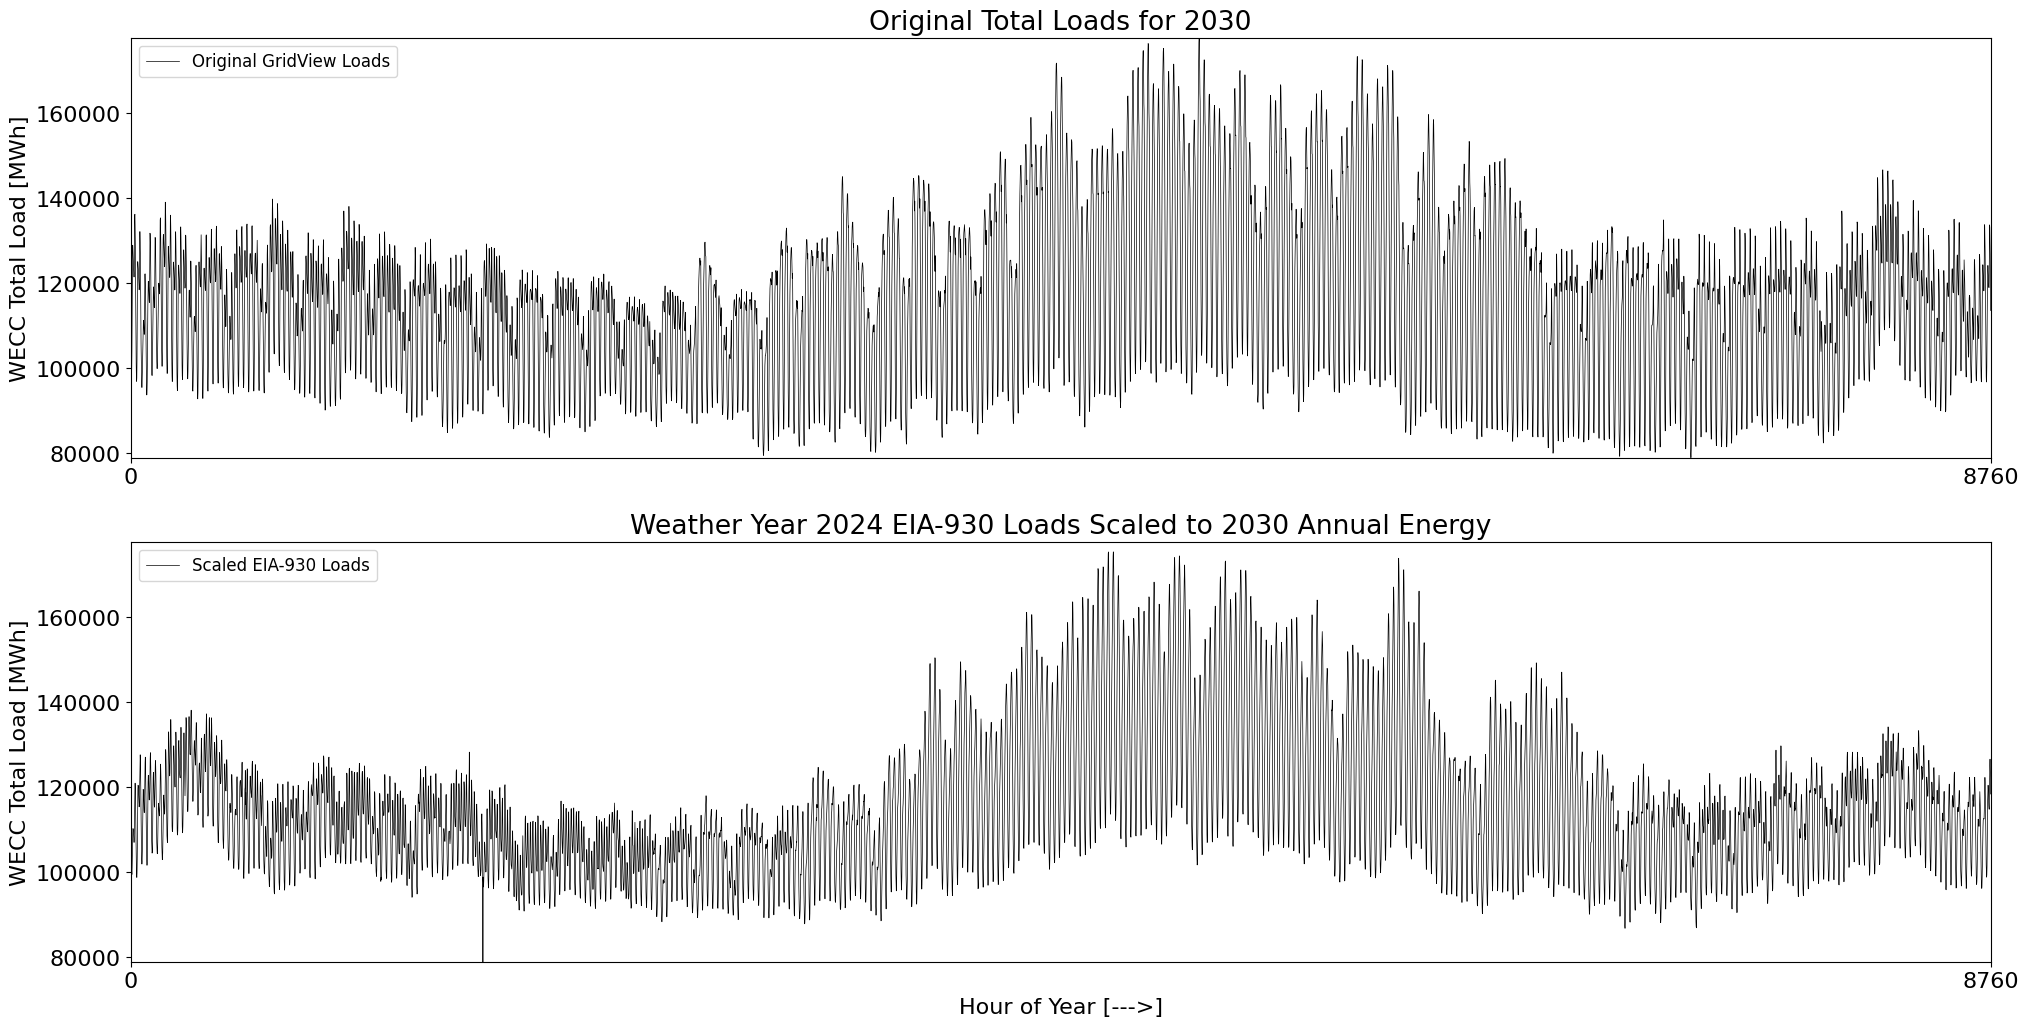

In [36]:
output_df = plot_load_time_series(data_dir = data_dir,
                                  year_to_process = 2024,
                                  image_output_dir = plot_dir, 
                                  image_resolution = 300, 
                                  save_images = True)

output_df
